In [1]:
import pandas as pd
import yfinance as yf

In [2]:
calls = pd.read_csv("../data/options/SPY_Calls.csv")

In [3]:
spy = yf.Ticker("SPY")

spy_price = spy.history(period="1d")["Close"].iloc[-1]

print(f"Current SPY Price: {spy_price:.2f}")

Current SPY Price: 738.25


In [4]:
calls["Distance"] = abs(calls["strike"] - spy_price)

In [5]:
atm_option = calls.loc[calls["Distance"].idxmin()]

print(atm_option)

contractSymbol              SPY260724C00738000
lastTradeDate        2026-07-24 14:00:13+00:00
strike                                   738.0
lastPrice                                 1.38
bid                                       1.37
ask                                       1.39
change                                    -2.1
percentChange                       -59.999996
volume                                 36308.0
openInterest                              5694
impliedVolatility                     0.081796
inTheMoney                                True
contractSize                           REGULAR
currency                                   USD
Distance                                  0.25
Name: 111, dtype: object


In [6]:
print(atm_option[
    [
        "strike",
        "lastPrice",
        "bid",
        "ask",
        "volume",
        "openInterest",
        "impliedVolatility",
        "inTheMoney"
    ]
])

strike                  738.0
lastPrice                1.38
bid                      1.37
ask                      1.39
volume                36308.0
openInterest             5694
impliedVolatility    0.081796
inTheMoney               True
Name: 111, dtype: object


In [7]:
calls = calls.sort_values("strike")

In [8]:
calls[
    [
        "strike",
        "impliedVolatility",
        "inTheMoney"
    ]
].head(15)

,strike,impliedVolatility,inTheMoney
0,500.0,0.000010,True
1,505.0,3.661134,True
2,510.0,3.578126,True
3,515.0,3.500978,True
4,520.0,3.419923,True
5,525.0,3.359377,True
6,530.0,3.290041,True
7,540.0,6.030764,True
8,550.0,2.983401,True
9,555.0,2.859378,True


Matplotlib is building the font cache; this may take a moment.


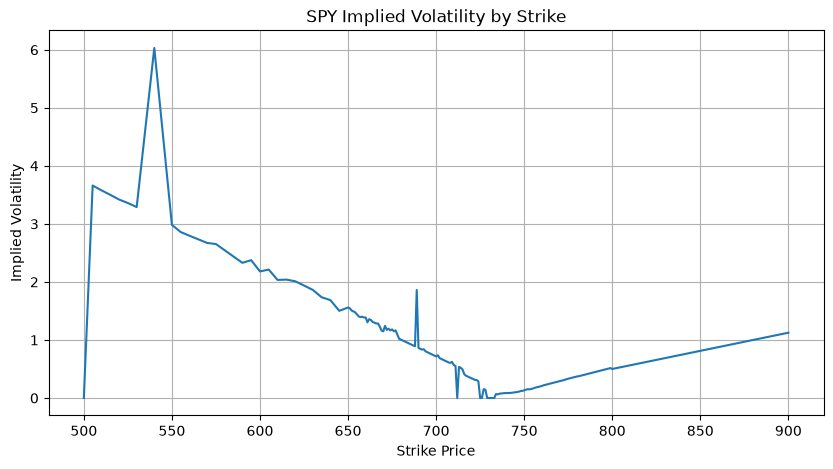

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    calls["strike"],
    calls["impliedVolatility"]
)

plt.title("SPY Implied Volatility by Strike")

plt.xlabel("Strike Price")

plt.ylabel("Implied Volatility")

plt.grid(True)

plt.show()

In [10]:
calls.to_csv(
    "../data/options/SPY_Calls_Filtered.csv",
    index=False
)